In [13]:
import os
import re
import numpy as np
import tifffile
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
from natsort import natsorted
import pandas as pd
import glob

import matplotlib.patches as mpatches
import matplotlib.path as mpath 
from matplotlib.collections import PathCollection
import matplotlib.colors as mcolors

In [2]:
# Function to sort files naturally
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

# Function to calculate SSIM
def calculate_ssim(original_file, compressed_file):
    ssim_scores = []
    with tifffile.TiffFile(original_file) as tif_original:
        with tifffile.TiffFile(compressed_file) as tif_compressed:
            for original_frame, compressed_frame in zip(tif_original.series[0].pages, tif_compressed.series[0].pages):
                original_image = original_frame.asarray()
                compressed_image = compressed_frame.asarray()
                score = ssim(original_image, compressed_image, data_range=compressed_image.max() - compressed_image.min())
                ssim_scores.append(score)
    return np.median(ssim_scores) 

# New function to calculate SSIM
def calculate_ssim_folder(original_folder, compressed_folder):
    ssim_results = []
    original_files = natsorted([f for f in os.listdir(original_folder) if f.endswith('.tiff') and not f.startswith('.')])
    compressed_files = natsorted([f for f in os.listdir(compressed_folder) if f.endswith('.tiff') and not f.startswith('.')])
    
    for original_file, compressed_file in zip(original_files, compressed_files):
        ssim_scores = []
        try:
            with tifffile.TiffFile(os.path.join(original_folder, original_file)) as tif_original:
                with tifffile.TiffFile(os.path.join(compressed_folder, compressed_file)) as tif_compressed:
                    for original_frame, compressed_frame in zip(tif_original.series[0].pages, tif_compressed.series[0].pages):
                        original_image = original_frame.asarray()
                        compressed_image = compressed_frame.asarray()
                        score = ssim(original_image, compressed_image, data_range=compressed_image.max() - compressed_image.min())
                        ssim_scores.append(score)
            if ssim_scores:
                median_ssim = np.median(ssim_scores)
                ssim_results.append({'original_file': original_file, 'compressed_file': compressed_file, 'ssim': median_ssim})
        except Exception as e:
            print(f"Error processing files {original_file} and {compressed_file}: {e}")
    return ssim_results


# Function to get the total size of files in a folder
def get_total_size_of_files(folder_path, file_extensions):
    total_size = 0
    for file in os.listdir(folder_path):
        if any(file.endswith(ext) for ext in file_extensions):
            total_size += os.path.getsize(os.path.join(folder_path, file))
    return total_size

# Function to extract the k and lev values from the label
def extract_k_lev(label):
    """
    Extracts the k and lev values from the label.
    Assumes the label format is like 'sparz_k5_rt35_lev0'.
    """
    k_match = re.search(r'_k(\d+)_', label)
    lev_match = re.search(r'_lev(\d+)', label)
    k_value = int(k_match.group(1)) if k_match else None
    lev_value = int(lev_match.group(1)) if lev_match else None
    return k_value, lev_value

# Genomic data

### SSIM versus file size grid search

In [5]:
# Nir et al data
main_folder = '/Volumes/T9/compression_grid_search'
original_files = '/Volumes/T9/compression/nir_raw/raw_16bit'


In [6]:
# Get orginal file size from all tiff files
original_file_size = get_total_size_of_files(original_files, ['.tiff'])
print(f'Original file size: {original_file_size / 1e6:.2f} MB')

Original file size: 15892.81 MB


In [8]:
# Create CSV file of SSIM and file size
ssim_df_list = []
for folder in natsorted(os.listdir(main_folder)):
    if folder.startswith('.'):
        continue
    print(folder)
    uncompressed_folder = os.path.join(main_folder, folder, 'uncompressed')
    
    ssim_results = calculate_ssim_folder(original_files, uncompressed_folder)
    total_file_size = get_total_size_of_files(os.path.join(main_folder, folder), ['.mp4', '.npz'])
    print(f'Total file size: {total_file_size / 1e6:.2f} MB')
    file_size_percentage = (total_file_size / original_file_size) * 100
    print(f'File size percentage: {file_size_percentage:.2f}%')
    k, lev = extract_k_lev(folder)
    threshold = int(re.search(r'rt(\d+)', folder).group(1)) 
    
    for result in ssim_results:
        ssim_df_list.append({'Folder': folder, 'original_file': result['original_file'], 'compressed_file': result['compressed_file'], 'SSIM': result['ssim'], 'Size': total_file_size, 'percentage_size': file_size_percentage, 'k': k, 'lev': lev, 'threshold': threshold})

ssim_df = pd.DataFrame(ssim_df_list)
ssim_df.to_csv('/Users/laurabreimann/Desktop/nir_ssim.csv', index=False)

sparz_k7_rt15_lev0
Total file size: 25823.76 MB
File size percentage: 162.49%
sparz_k7_rt15_lev1
Total file size: 18970.68 MB
File size percentage: 119.37%
sparz_k7_rt15_lev2
Total file size: 18046.99 MB
File size percentage: 113.55%
sparz_k7_rt15_lev3
Total file size: 16149.45 MB
File size percentage: 101.61%
sparz_k7_rt25_lev0
Total file size: 23938.68 MB
File size percentage: 150.63%
sparz_k7_rt25_lev1
Total file size: 17085.60 MB
File size percentage: 107.51%
sparz_k7_rt25_lev2
Total file size: 16161.92 MB
File size percentage: 101.69%
sparz_k7_rt25_lev3
Total file size: 14264.38 MB
File size percentage: 89.75%
sparz_k7_rt35_lev0
Total file size: 18662.07 MB
File size percentage: 117.42%
sparz_k7_rt35_lev1
Total file size: 11808.99 MB
File size percentage: 74.30%
sparz_k7_rt35_lev2
Total file size: 10885.30 MB
File size percentage: 68.49%
sparz_k7_rt35_lev3
Total file size: 8987.77 MB
File size percentage: 56.55%
sparz_k7_rt45_lev0
Total file size: 14198.58 MB
File size percentage:

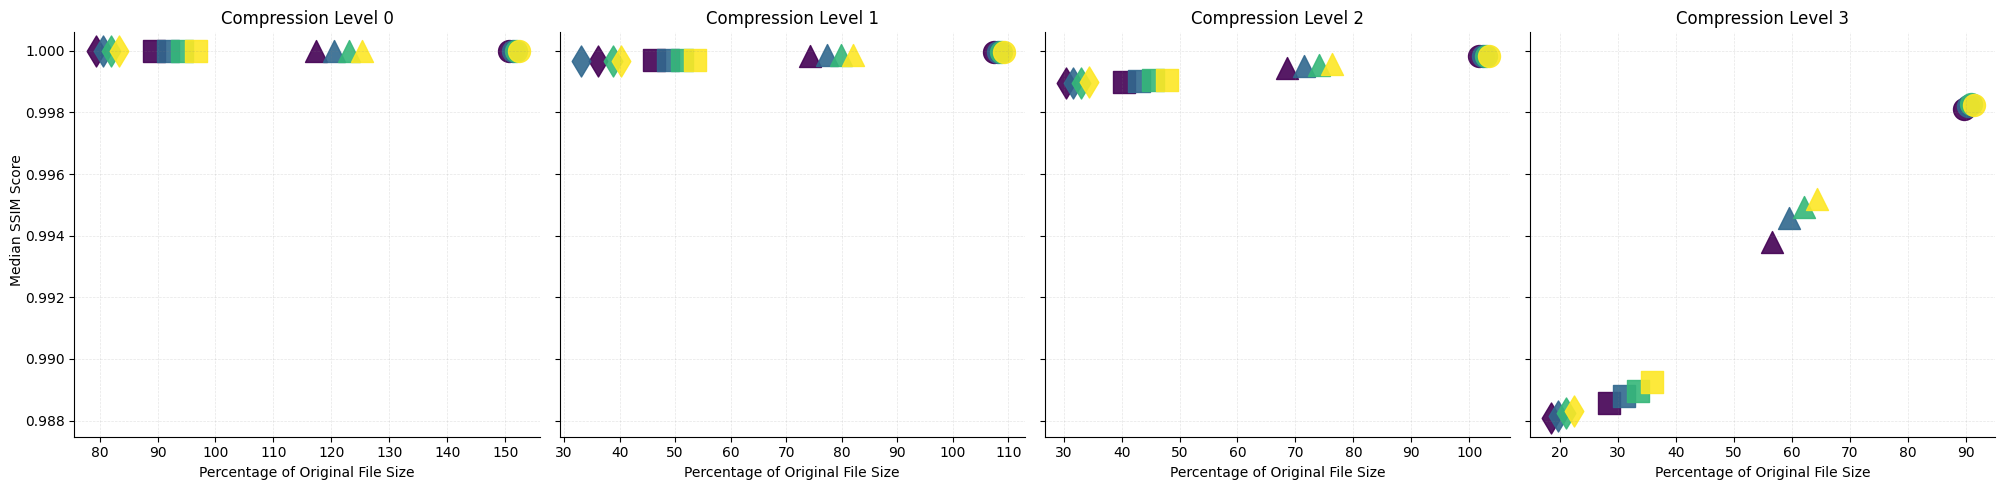

In [11]:
# Read the CSV file
csv_file = '/Users/laurabreimann/Desktop/nir_ssim.csv'
ssim_df = pd.read_csv(csv_file)

# Define colors and markers based on provided specifications
k_values = [7, 9, 11, 13]
k_colors = plt.cm.viridis(np.linspace(0, 1, len(k_values)))
threshold_markers = {25: 'o', 35: '^', 45: 's', 55: 'd'}

# Create a color map for 'k' values
color_map = {k: color for k, color in zip(k_values, k_colors)}

# Calculate the median of medians for SSIM for each folder
folder_stats = ssim_df.groupby('Folder').agg({
    'SSIM': 'median',  # Median of medians for SSIM
    'percentage_size': 'first',  # File size percentage (same for all files in the folder)
    'k': 'first',
    'lev': 'first',
    'threshold': 'first'
}).reset_index()

# Create facet plot
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for i, (level, group) in enumerate(folder_stats.groupby('lev')):
    ax = axs[i]
    ax.set_xlabel('Percentage of Original File Size')
    ax.set_title(f'Compression Level {level}')
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.2, zorder=0)
    for k, data in group.groupby('k'):
        for rt, rt_data in data.groupby('threshold'):
            if rt in threshold_markers:
                ax.scatter(rt_data['percentage_size'], rt_data['SSIM'], 
                           color=color_map[k], 
                           s=250, 
                           marker=threshold_markers[rt], 
                           alpha=0.9, 
                           label=f'k={k}, rt={rt}')
    #ax.set_xlim(0, 50)

# Remove lines on top and right
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Set common Y axis label
fig.text(0, 0.55, 'Median SSIM Score', va='center', rotation='vertical')

# Add a legend
handles, labels = ax.get_legend_handles_labels()
#fig.legend(handles, labels, loc='upper right')

plt.tight_layout()

# Save the plot as a PDF
output_file = '/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/Figure_3a_SSIM_filesize_240705_2.pdf'
plt.savefig(output_file, format='pdf')
#plt.close()

## Overview images from grid search

In [14]:
# Define the parameters used in grid search
kernel_sizes = [7,9,11,13]  
rel_thresholds = [0.25, 0.35, 0.45, 0.55]  
compression_levels = [0, 1, 2, 3]  

In [17]:
# Reconstruction of the full array from the sparse data
def reconstruct_array(data):
    shape = tuple(data['shape'])
    fill_value = data['fill_value']
    coords = data['coords']
    sparse_data = data['data']

    full_array = np.full(shape, fill_value)
    for i, coord in enumerate(zip(*coords)):
        full_array[coord] = sparse_data[i]
    return full_array

# Load and plot the npz files
def load_and_plot_npz_files(folder_path, compression_level=0):
    # Double the number of columns to accommodate two images per condition
    fig, axs = plt.subplots(len(kernel_sizes), len(rel_thresholds) * 2, figsize=(15, 10))

    for root, dirs, files in os.walk(folder_path):
        for dir in dirs:
            kernel_size, rel_threshold, comp_level = extract_parameters(dir)

            if comp_level == compression_level:
                if kernel_size in kernel_sizes and rel_threshold in rel_thresholds:
                    file_paths = ['img_01_01_bp1.npz', 'img_01_01_bp2.npz']
                    for index, file_name in enumerate(file_paths):
                        file_path = os.path.join(root, dir, file_name)
                        if os.path.exists(file_path):
                            data = np.load(file_path)
                            full_array = reconstruct_array(data)
                            selected_image = full_array[25]

                            # Find the correct subplot
                            i = kernel_sizes.index(kernel_size)
                            j = rel_thresholds.index(rel_threshold) * 2 + index

                            # Set color for values below the colormap range
                            cmap = plt.cm.gray
                            cmap.set_under('darkgray')

                            # Plot the selected image
                            axs[i, j].imshow(selected_image, cmap=cmap, interpolation='none', norm=mcolors.Normalize(vmin=0.1, vmax=np.max(selected_image)))
                            axs[i, j].axis('off')

                            # Set title for the first image of the pair
                            # if index == 0:
                            #     axs[i, j].set_title(f'k{kernel_size} thr{rel_threshold}')
   

    plt.tight_layout()

      # Save the plot as a PDF
    plt.savefig('/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/npz_profiles_figure3_nir.pdf', format='pdf')  

    plt.show()

# Extract the parameters from the folder name after the grid search
def extract_parameters(folder_name):
    match = re.search(r'k(\d+)_rt(\d+)_lev(\d+)', folder_name)
    if match:
        kernel_size = int(match.group(1))
        rel_threshold = float(f"0.{match.group(2)}")
        compression_level = int(match.group(3))
        return kernel_size, rel_threshold, compression_level
    else:
        return None, None, None

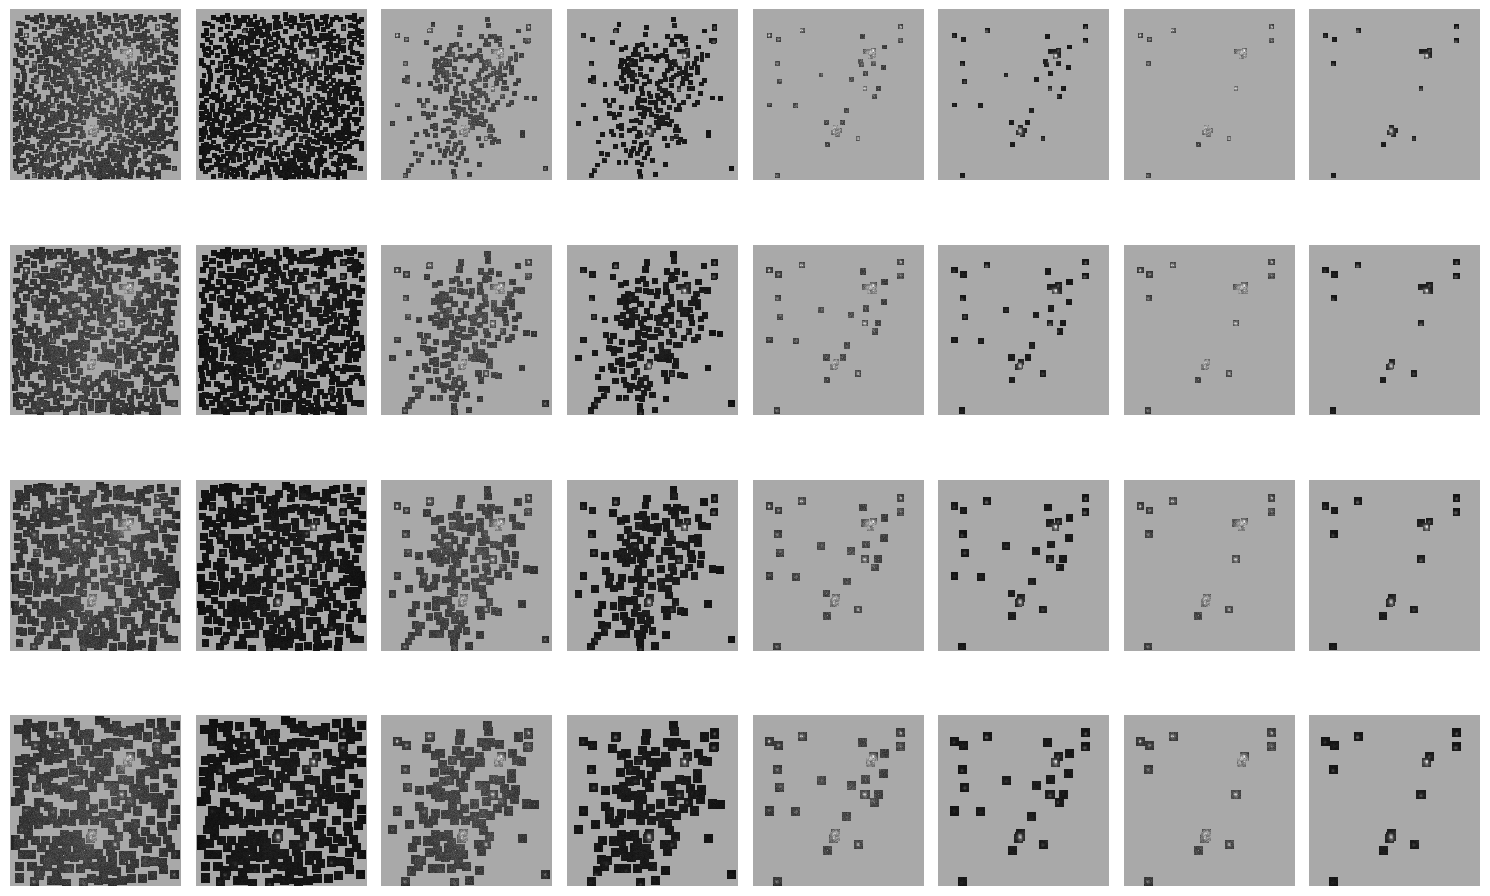

In [18]:

main_folder_path = "/Users/laurabreimann/Library/CloudStorage/Dropbox-HMS/data_compression_localizations/figure_3_data/grid_search"
# Load and plot
load_and_plot_npz_files(main_folder_path)

# Image comparison - SSIM

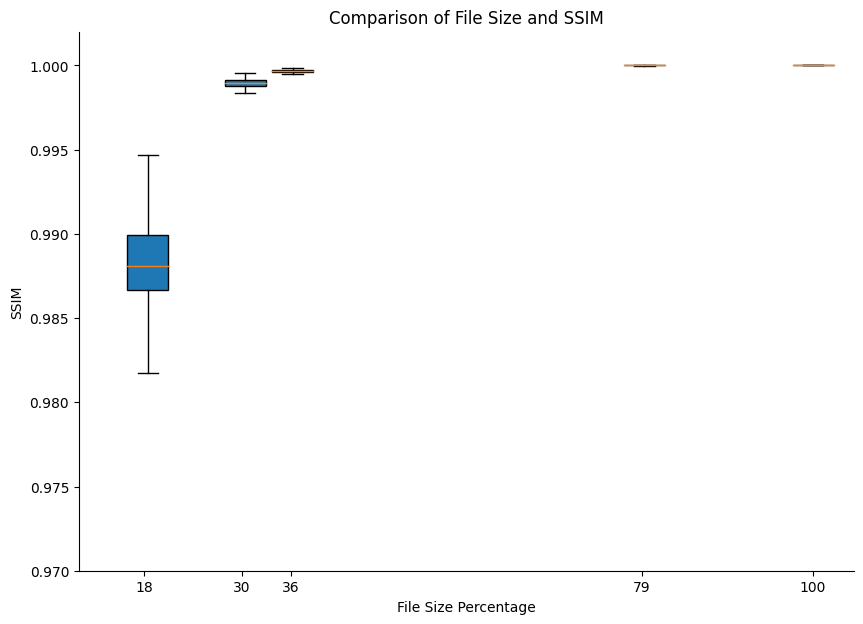

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
csv_file = '/Users/laurabreimann/Desktop/nir_ssim.csv'
ssim_single_df = pd.read_csv(csv_file)

# Specify the folders you want to include in the plot
selected_folders = ['sparz_k7_rt55_lev0','sparz_k7_rt55_lev1', 'sparz_k7_rt55_lev2',  'sparz_k7_rt55_lev3']

# Filter the DataFrame for the selected folders
filtered_df = ssim_single_df[ssim_single_df['Folder'].isin(selected_folders)]

# Prepare the raw image data
raw_image_data = pd.DataFrame({
    'Folder': ['Raw Image'],
    'percentage_size': [100.0],
    'SSIM': [1.0]
})

# Add the raw image data to the filtered DataFrame
combined_df = pd.concat([filtered_df, raw_image_data])

# Prepare data for plotting
data_for_plotting = []
positions = []

for folder in selected_folders + ['Raw Image']:
    folder_data = combined_df[combined_df['Folder'] == folder]['SSIM']
    folder_size = combined_df[combined_df['Folder'] == folder]['percentage_size'].mean()
    data_for_plotting.append(folder_data)
    positions.append(folder_size)

# Plotting
plt.figure(figsize=(10, 7))
plt.boxplot(data_for_plotting, positions=positions, widths=5, patch_artist=True, showfliers=False)

plt.xlabel('File Size Percentage')
plt.ylabel('SSIM')
plt.ylim(0.97, 1.002)
plt.xlim(10, 105)
plt.title('Comparison of File Size and SSIM')

# Customizing the plot appearance
plt.grid(False)  # Remove the background lines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Round x-axis tick labels to the nearest integer
plt.xticks(ticks=np.round(plt.gca().get_xticks()), labels=np.round(plt.gca().get_xticks()).astype(int))

#Save the plot as PDF
plt.savefig('/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/SSIM_Figure3b.pdf')    

plt.show()


# Localization comparison - Jaccard

# Structure comparison